In [4]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import yfinance as yf
import pandas as pd

tesla=yf.download("TSLA", start="2020-01-01", end="2021-01-01")
gamestop = yf.download("GME", start="2020-01-01", end="2021-01-01")

print('Tesla shape:', tesla.shape)
print("Gamestop shape:", gamestop.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Tesla shape: (253, 5)
Gamestop shape: (253, 5)


In [6]:
print(tesla.columns.tolist())
tesla.head()

[('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [7]:
tesla = yf.download("TSLA", start="2021-01-01", end="2021-12-31")
tesla.columns = tesla.columns.get_level_values(0)
print(tesla.index.min(), tesla.index.max())
tesla.head()

[*********************100%***********************]  1 of 1 completed

2021-01-04 00:00:00 2021-12-30 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000
2021-01-07,272.013336,272.329987,258.399994,259.209991,154496700
2021-01-08,293.339996,294.829987,279.463318,285.333344,225166500


In [8]:
gamestop = yf.download("GME", start="2021-01-01", end="2021-12-31")
gamestop.columns = gamestop.columns.get_level_values(0)
print(gamestop.index.min(), gamestop.index.max())
gamestop.head()

[*********************100%***********************]  1 of 1 completed

2021-01-04 00:00:00 2021-12-30 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,4.3125,4.7750,4.2875,4.7500,40090000
2021-01-05,4.3425,4.5200,4.3075,4.3375,19846000
2021-01-06,4.5900,4.7450,4.3325,4.3350,24224800
2021-01-07,4.5200,4.8625,4.5050,4.6175,24517200
2021-01-08,4.4225,4.5750,4.2700,4.5450,25928000


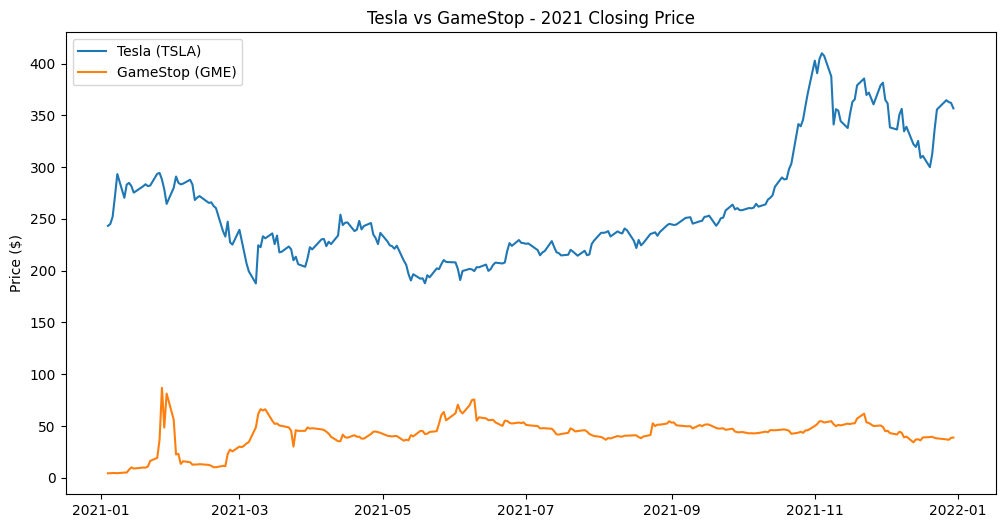

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(tesla.index, tesla["Close"], label="Tesla (TSLA)")
plt.plot(gamestop.index, gamestop["Close"], label="GameStop (GME)")
plt.legend()
plt.title("Tesla vs GameStop - 2021 Closing Price")
plt.ylabel("Price ($)")
plt.show()

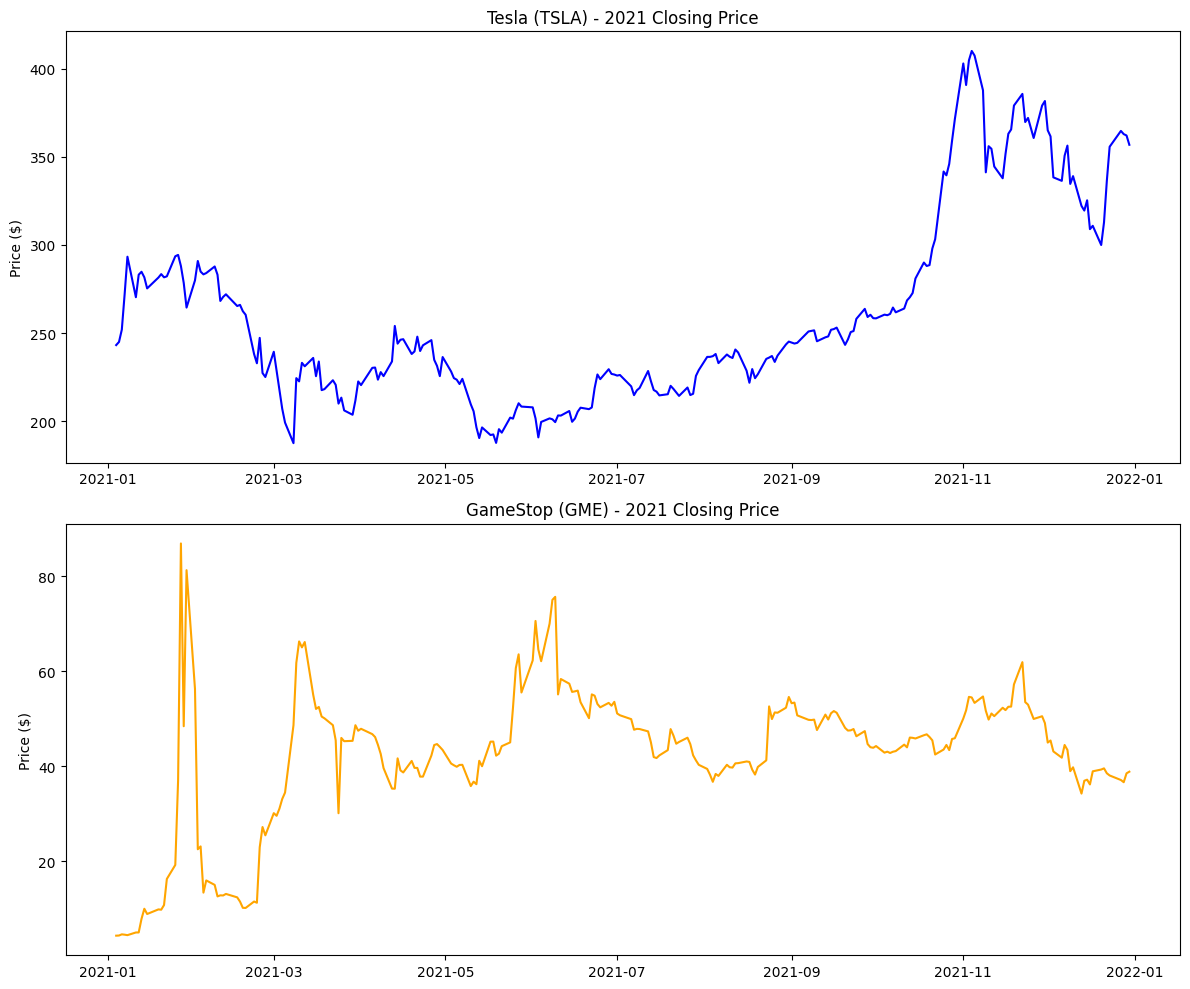

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12,10))

axes[0].plot(tesla.index, tesla["Close"], color="blue")
axes[0].set_title("Tesla (TSLA) - 2021 Closing Price")
axes[0].set_ylabel("Price ($)")

axes[1].plot(gamestop.index, gamestop["Close"], color="orange")
axes[1].set_title("GameStop (GME) - 2021 Closing Price")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

In [11]:
tesla_shares = 1000 / tesla["Close"].iloc[0]
tesla_final_value = tesla_shares * tesla["Close"].iloc[-1]

gamestop_shares = 1000 / gamestop["Close"].iloc[0]
gamestop_final_value = gamestop_shares * gamestop["Close"].iloc[-1]

print(f"Tesla: $1000 invested on Jan 4 2021 would be worth ${tesla_final_value:.2f} by Dec 30 2021")
print(f"GameStop: $1000 invested on Jan 4 2021 would be worth ${gamestop_final_value:.2f} by Dec 30 2021")

Tesla: $1000 invested on Jan 4 2021 would be worth $1466.68 by Dec 30 2021
GameStop: $1000 invested on Jan 4 2021 would be worth $9004.64 by Dec 30 2021


In [12]:
def max_drawdown(prices):
    cumulative_max= prices.cummax()
    drawdown= (prices- cumulative_max)/ cumulative_max
    return drawdown.min()

tesla_dd = max_drawdown(tesla["Close"])
gamestop_dd=max_drawdown(gamestop["Close"])

print(f"    Tesla Max Drawdown: {tesla_dd:.2%}")
print(f"    GameStop Max Drawdown: {gamestop_dd:.2%}")

    Tesla Max Drawdown: -36.25%
    GameStop Max Drawdown: -88.32%


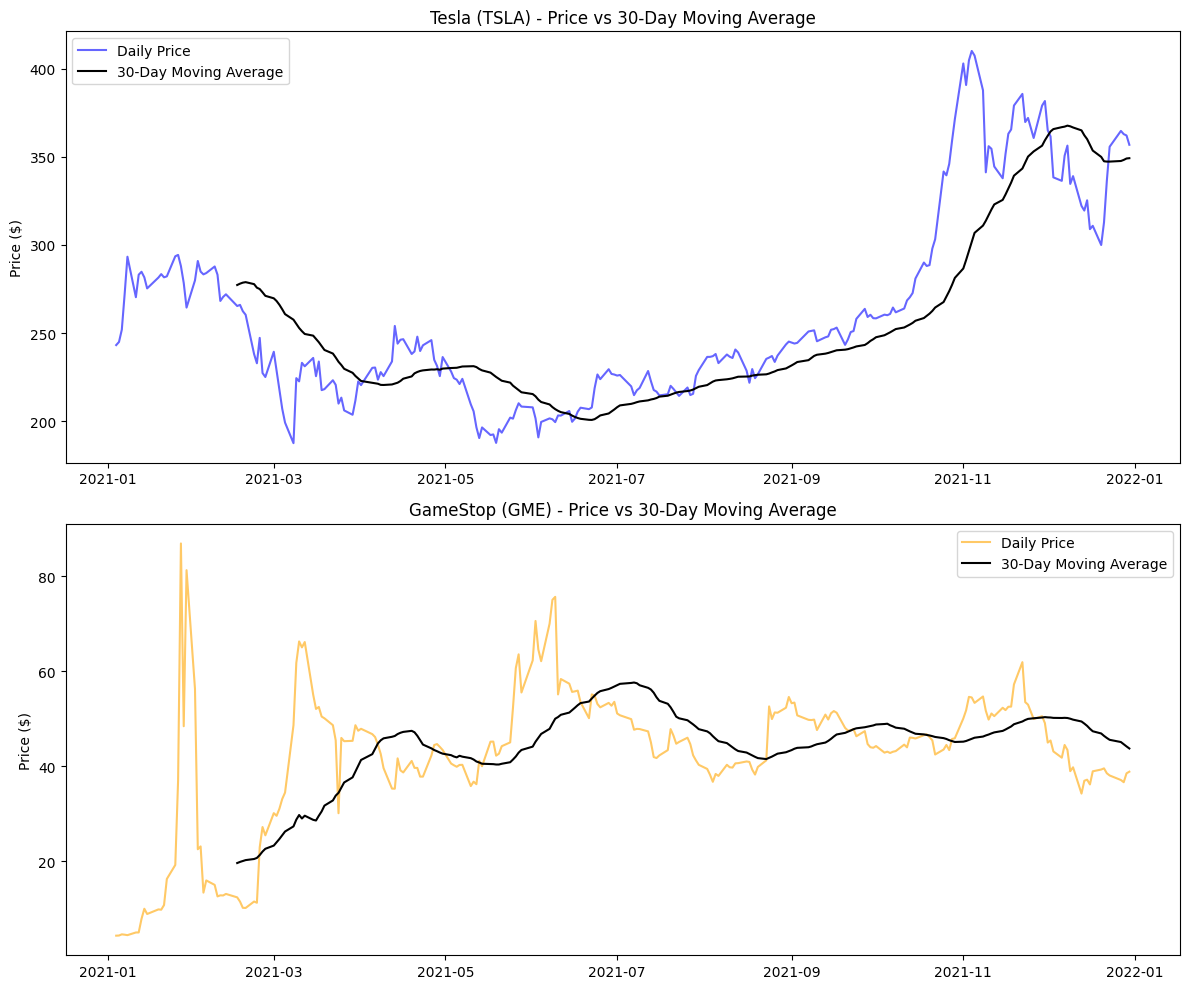

In [13]:
tesla["MA30"] = tesla["Close"].rolling(window=30).mean()
gamestop["MA30"] = gamestop["Close"].rolling(window=30).mean()

fig, axes = plt.subplots(2, 1, figsize=(12,10))

axes[0].plot(tesla.index, tesla["Close"], label="Daily Price", color="blue", alpha=0.6)
axes[0].plot(tesla.index, tesla["MA30"], label="30-Day Moving Average", color="black")
axes[0].set_title("Tesla (TSLA) - Price vs 30-Day Moving Average")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

axes[1].plot(gamestop.index, gamestop["Close"], label="Daily Price", color="orange", alpha=0.6)
axes[1].plot(gamestop.index, gamestop["MA30"], label="30-Day Moving Average", color="black")
axes[1].set_title("GameStop (GME) - Price vs 30-Day Moving Average")
axes[1].set_ylabel("Price ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig("tesla_gamestop_moving_average.png")
plt.show()

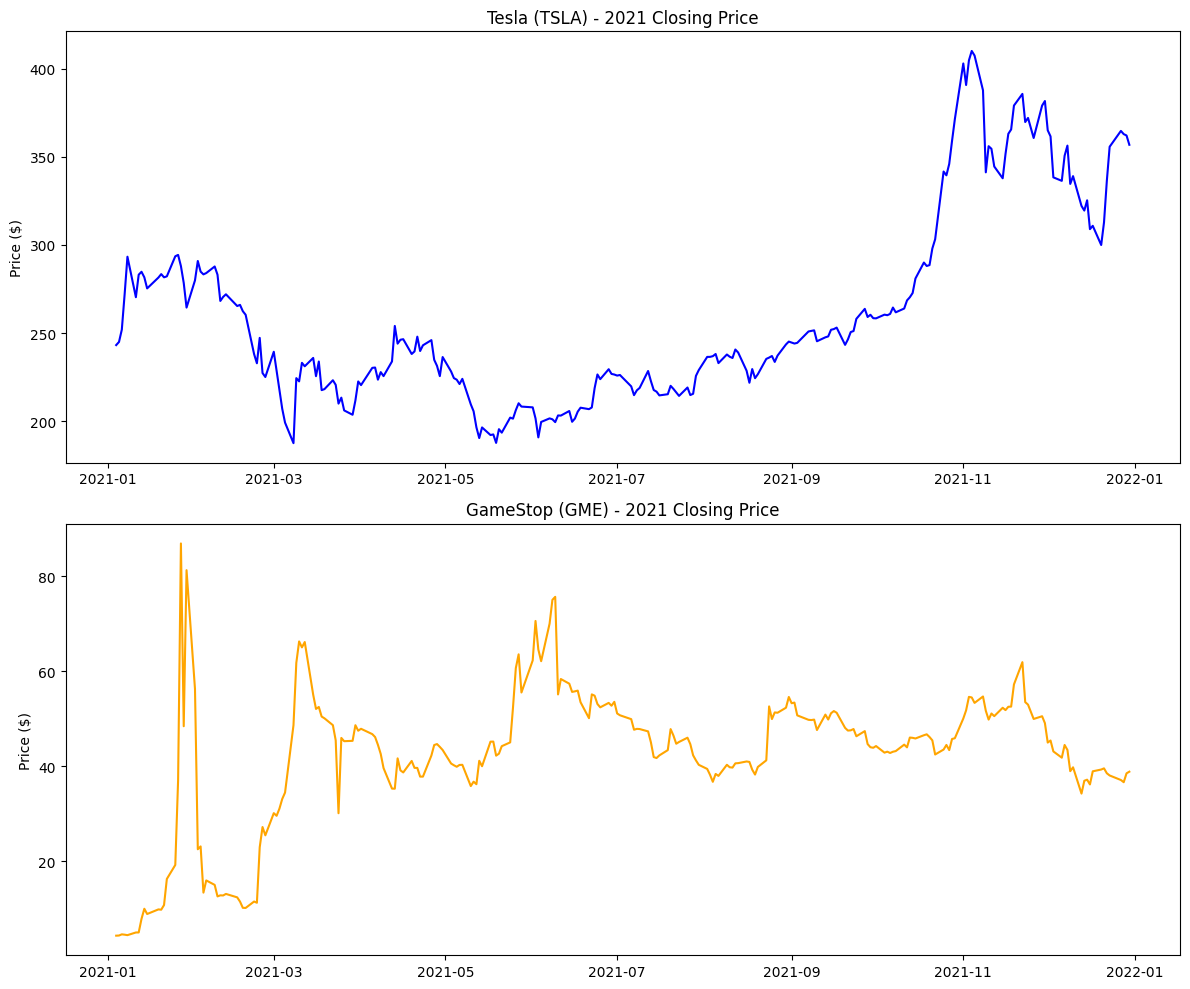

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12,10))

axes[0].plot(tesla.index, tesla["Close"], color="blue")
axes[0].set_title("Tesla (TSLA) - 2021 Closing Price")
axes[0].set_ylabel("Price ($)")

axes[1].plot(gamestop.index, gamestop["Close"], color="orange")
axes[1].set_title("GameStop (GME) - 2021 Closing Price")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.savefig("tesla_gamestop_separate.png")
plt.show()